In [1]:
#pip install gurobipy

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import gurobipy as gp
from gurobipy import GRB

In [36]:

# 1. LOAD AND PREPARE DATA
returns = pd.read_csv(
    r"C:\Users\liman\OneDrive - University of Johannesburg\MFE\2026 First Semester\Portfolio Optimisation and Risk Allocation\Group Assignment\dow_returns_2000_2003.csv",
    parse_dates=["Date"],
    index_col="Date"
)

tbill = pd.read_csv(
    r"C:\Users\liman\OneDrive - University of Johannesburg\MFE\2026 First Semester\Portfolio Optimisation and Risk Allocation\Group Assignment\us_tbill_3month_2000_2003.csv",
    parse_dates=["Date"],
    index_col="Date"
)
# Take first 8 quarters to match paper
returns = returns.iloc[:8]
tbill = tbill.iloc[:8]

In [25]:

# Convert T-bill from annual % to quarterly decimal
rf_quarterly = tbill.values / 100 / 4

# Calculate excess returns
excess_returns = returns.values - rf_quarterly

# Calculate d and D
d = excess_returns.mean(axis=0)
cov_matrix = np.cov(excess_returns.T)
n = len(d)  
# with regularization
epsilon = 1e-6
D = cov_matrix + np.outer(d, d) + epsilon * np.eye(n)

print(f"d shape: {d.shape}")
print(f"D shape: {D.shape}")
print(f"d values: {d}")

d shape: (10,)
D shape: (10, 10)
d values: [-0.00405973  0.05864866  0.06356952 -0.00767587  0.08647931  0.04052737
  0.14048504  0.06281383  0.03720833  0.01360346]


In [37]:
# Check your excess returns directly
print("Excess returns summary:")
excess_df = pd.DataFrame(excess_returns, columns=returns.columns)
print(excess_df.describe())

# Check MO specifically
print("\nMO excess returns by quarter:")
print(excess_df['MO'])

# Check average raw returns
print("\nRaw returns (quarterly):")
print(returns.mean())

# Check T-bill rates used
print("\nT-bill quarterly rates used:")
print(rf_quarterly.flatten())

Excess returns summary:
            AIG        BA       CAT       IBM       JNJ       MMM        MO  \
count  8.000000  8.000000  8.000000  8.000000  8.000000  8.000000  8.000000   
mean  -0.004060  0.058649  0.063570 -0.007676  0.086479  0.040527  0.140485   
std    0.121383  0.277285  0.222594  0.199381  0.181040  0.165069  0.179080   
min   -0.193402 -0.401519 -0.148328 -0.258648 -0.175153 -0.143691 -0.042831   
25%   -0.089724 -0.047169 -0.094621 -0.156784  0.026795 -0.087918  0.029640   
50%    0.015161  0.053349  0.013144 -0.036813  0.102331  0.031635  0.096406   
75%    0.050495  0.180664  0.137800  0.134884  0.115315  0.121952  0.189960   
max    0.206942  0.531936  0.529089  0.316148  0.441165  0.316189  0.501027   

             PG       RTX       XOM  
count  8.000000  8.000000  8.000000  
mean   0.062814  0.037208  0.013603  
std    0.128519  0.225223  0.084725  
min   -0.208510 -0.369163 -0.098698  
25%    0.009969 -0.076557 -0.043933  
50%    0.114122  0.058090 -0.001685 

In [47]:
# Store results
all_weights = []
all_returns = []
all_selected = []

print("RECURSIVE ROLLING WINDOW (No look-ahead bias)")
print("=" * 60)

# Start from t=2 (Q3) - need at least 2 quarters for covariance
for t in range(2, 8):  # t=2 to 7 (quarters 3 to 8)
    print(f"\nQUARTER {t+1} (Starting {returns.index[t].strftime('%Y-%m-%d')})")
    
    # Use data from quarters 0 to t-1 for estimation
    train_data = returns.iloc[0:t]  # Q1 to Q(t-1)
    rf_train = rf_quarterly[0:t]
    
    # Calculate excess returns
    excess_train = train_data.values - rf_train.reshape(-1, 1)
    
    # Calculate d and D
    d_train = excess_train.mean(axis=0)
    cov_train = np.cov(excess_train.T)
    D_train = cov_train + np.outer(d_train, d_train) + 1e-6 * np.eye(n)
    
    # Solve CCQO
    k_star, z_star = solve_ccqo_exact(d_train, D_train, q=5)
    
    # Convert to proportions
    selected_idx = [i for i in range(n) if z_star[i] > 0.5]
    selected_stocks = [returns.columns[i] for i in selected_idx]
    selected_weights_raw = k_star[selected_idx]
    total_raw = sum(selected_weights_raw)
    proportions = selected_weights_raw / total_raw
    
    # Create weight vector
    weights = np.zeros(n)
    for j, idx in enumerate(selected_idx):
        weights[idx] = proportions[j]
    
    # Calculate portfolio return for THIS quarter
    portfolio_return = sum(weights[i] * returns.iloc[t, i] for i in range(n))
    
    all_weights.append(weights)
    all_returns.append(portfolio_return)
    all_selected.append(selected_stocks)
    
    print(f"Training: quarters 1 to {t}")
    print(f"Selected: {selected_stocks}")
    print(f"Return for Q{t+1}: {portfolio_return:.4f} ({portfolio_return*100:.2f}%)")

# Results for 6 quarters (Q3 to Q8)
print("\n" + "=" * 60)
print(f"SUMMARY: {len(all_returns)} quarters (Q3 to Q8)")
print("=" * 60)
for t in range(len(all_returns)):
    print(f"Q{t+3}: Return = {all_returns[t]:.4f} ({all_returns[t]*100:.2f}%)")

# Calculate statistics
if len(all_returns) > 0:
    print(f"\nAverage quarterly return: {np.mean(all_returns):.6f}")
    print(f"Std dev quarterly return: {np.std(all_returns):.6f}")
    print(f"Sharpe ratio (quarterly): {np.mean(all_returns)/np.std(all_returns):.4f}")
    print(f"Sharpe ratio (annualized): {np.mean(all_returns)/np.std(all_returns)*2:.4f}")




RECURSIVE ROLLING WINDOW (No look-ahead bias)

QUARTER 3 (Starting 2000-12-31)
Training: quarters 1 to 2
Selected: ['AIG', 'BA', 'CAT', 'PG', 'XOM']
Return for Q3: 0.0415 (4.15%)

QUARTER 4 (Starting 2001-03-31)
Training: quarters 1 to 3
Selected: ['AIG', 'BA', 'MO', 'PG', 'XOM']
Return for Q4: -0.0699 (-6.99%)

QUARTER 5 (Starting 2001-06-30)
Training: quarters 1 to 4
Selected: ['AIG', 'BA', 'IBM', 'MO', 'XOM']
Return for Q5: 0.1159 (11.59%)

QUARTER 6 (Starting 2001-09-30)
Training: quarters 1 to 5
Selected: ['AIG', 'IBM', 'MO', 'PG', 'XOM']
Return for Q6: -0.1059 (-10.59%)

QUARTER 7 (Starting 2001-12-31)
Training: quarters 1 to 6
Selected: ['AIG', 'IBM', 'JNJ', 'MO', 'XOM']
Return for Q7: 0.1140 (11.40%)

QUARTER 8 (Starting 2002-03-31)
Training: quarters 1 to 7
Selected: ['AIG', 'IBM', 'MO', 'PG', 'XOM']
Return for Q8: 0.0535 (5.35%)

SUMMARY: 6 quarters (Q3 to Q8)
Q3: Return = 0.0415 (4.15%)
Q4: Return = -0.0699 (-6.99%)
Q5: Return = 0.1159 (11.59%)
Q6: Return = -0.1059 (-10.59%)

In [48]:
# Transaction costs
alpha_tc = 0.0005  # 0.05% from paper's Table 1

wealth = 1
prev_weights = np.zeros(10)

for t in range(len(all_returns)):
    # Get weights for this quarter
    weights = all_weights[t]
    
    # Calculate turnover
    turnover = np.sum(np.abs(weights - prev_weights))
    tc = alpha_tc * turnover
    
    # Net return
    net_return = all_returns[t] - tc
    
    # Update wealth
    wealth *= (1 + net_return)
    
    print(f"Q{t+3}: Gross={all_returns[t]:.4f}, TC={tc:.6f}, Net={net_return:.4f}, Wealth={wealth:.4f}")
    
    prev_weights = weights.copy()

# Final Sharpe with TC (recalculate using net returns)
net_returns = [all_returns[t] - alpha_tc * np.sum(np.abs(all_weights[t] - (all_weights[t-1] if t>0 else np.zeros(10)))) for t in range(len(all_returns))]

print(f"\nSharpe without TC: 0.5843")
print(f"Sharpe with TC (0.05%): {np.mean(net_returns)/np.std(net_returns)*2:.4f}")

Q3: Gross=0.0415, TC=0.000500, Net=0.0410, Wealth=1.0410
Q4: Gross=-0.0699, TC=0.000362, Net=-0.0702, Wealth=0.9679
Q5: Gross=0.1159, TC=0.000580, Net=0.1154, Wealth=1.0795
Q6: Gross=-0.1059, TC=0.000058, Net=-0.1060, Wealth=0.9651
Q7: Gross=0.1140, TC=0.000125, Net=0.1139, Wealth=1.0750
Q8: Gross=0.0535, TC=0.000258, Net=0.0532, Wealth=1.1322

Sharpe without TC: 0.5843
Sharpe with TC (0.05%): 0.5774


In [56]:

# Assuming you already have returns, rf_quarterly, n defined
# and solve_ccqo_exact function defined

print("=" * 60)
print("CMV-STATIC (Buy and Hold with Transaction Costs)")
print("=" * 60)

# Use Q1-Q2 for estimation
train_static = returns.iloc[0:2]
rf_static = rf_quarterly[0:2]

excess_static = train_static.values - rf_static.reshape(-1, 1)
d_static = excess_static.mean(axis=0)
cov_static = np.cov(excess_static.T)
D_static = cov_static + np.outer(d_static, d_static) + 1e-6 * np.eye(n)

# Solve CCQO once
k_static, z_static = solve_ccqo_exact(d_static, D_static, q=5)

selected_idx_static = [i for i in range(n) if z_static[i] > 0.5]
selected_stocks_static = [returns.columns[i] for i in selected_idx_static]
selected_weights_raw_static = k_static[selected_idx_static]
total_static = sum(selected_weights_raw_static)
proportions_static = selected_weights_raw_static / total_static

# Create full weight vector (10 stocks)
static_weights = np.zeros(n)
for j, idx in enumerate(selected_idx_static):
    static_weights[idx] = proportions_static[j]

print(f"Static portfolio selected: {selected_stocks_static}")
print(f"Weights:")
for stock, w in zip(selected_stocks_static, proportions_static):
    print(f"  {stock}: {w:.4f}")

# Calculate returns for Q3 to Q8 (6 quarters)
static_returns = []
for t in range(2, 8):  # Q3 to Q8
    ret = sum(static_weights[i] * returns.iloc[t, i] for i in range(n))
    static_returns.append(ret)
    print(f"Q{t+1}: {ret:.4f} ({ret*100:.2f}%)")

# Calculate Sharpe without TC
mean_ret = np.mean(static_returns)
std_ret = np.std(static_returns)
sharpe_static_no_tc = mean_ret / std_ret * 2  # Annualized

print(f"\nCMV-static (No TC)")
print(f"Mean quarterly return: {mean_ret:.4f}")
print(f"Std dev quarterly: {std_ret:.4f}")
print(f"Sharpe (annualized): {sharpe_static_no_tc:.4f}")

# =============================================
# CMV-static WITH Transaction Costs
# =============================================

alpha_tc = 0.0005  # 0.05%

# For CMV-static: You buy ONCE at Q3, then hold
# Transaction cost occurs only at initial purchase (Q3)
# No further transaction costs because you don't rebalance

# Initial purchase at Q3 (prev_weights = all zeros)
prev_weights_cmv = np.zeros(n)
turnover_initial = np.sum(np.abs(static_weights - prev_weights_cmv))
tc_initial = alpha_tc * turnover_initial

print(f"\nCMV-static WITH Transaction Costs")
print(f"Initial turnover: {turnover_initial:.4f}")
print(f"Initial transaction cost: {tc_initial:.4f} ({tc_initial*100:.2f}%)")

# Net returns after transaction cost (only deducted at Q3)
static_returns_net = static_returns.copy()
static_returns_net[0] = static_returns[0] - tc_initial  # Only Q3 has TC

# Calculate wealth
wealth = 1
for t, ret in enumerate(static_returns_net):
    wealth *= (1 + ret)
    print(f"Q{t+3}: Gross={static_returns[t]:.4f}, Net={ret:.4f}, Wealth={wealth:.4f}")

# Calculate Sharpe with TC
mean_ret_tc = np.mean(static_returns_net)
std_ret_tc = np.std(static_returns_net)
sharpe_static_tc = mean_ret_tc / std_ret_tc * 2

print(f"\nMean quarterly return (with TC): {mean_ret_tc:.4f}")
print(f"Std dev quarterly (with TC): {std_ret_tc:.4f}")
print(f"Sharpe (annualized) with TC: {sharpe_static_tc:.4f}")


CMV-STATIC (Buy and Hold with Transaction Costs)
Static portfolio selected: ['AIG', 'BA', 'CAT', 'PG', 'XOM']
Weights:
  AIG: 0.2349
  BA: 0.5384
  CAT: 0.0000
  PG: 0.1279
  XOM: 0.0989
Q3: 0.0415 (4.15%)
Q4: -0.1571 (-15.71%)
Q5: 0.0252 (2.52%)
Q6: -0.2226 (-22.26%)
Q7: 0.1046 (10.46%)
Q8: 0.1434 (14.34%)

CMV-static (No TC)
Mean quarterly return: -0.0109
Std dev quarterly: 0.1338
Sharpe (annualized): -0.1623

CMV-static WITH Transaction Costs
Initial turnover: 1.0000
Initial transaction cost: 0.0005 (0.05%)
Q3: Gross=0.0415, Net=0.0410, Wealth=1.0410
Q4: Gross=-0.1571, Net=-0.1571, Wealth=0.8774
Q5: Gross=0.0252, Net=0.0252, Wealth=0.8995
Q6: Gross=-0.2226, Net=-0.2226, Wealth=0.6993
Q7: Gross=0.1046, Net=0.1046, Wealth=0.7724
Q8: Gross=0.1434, Net=0.1434, Wealth=0.8831

Mean quarterly return (with TC): -0.0109
Std dev quarterly (with TC): 0.1337
Sharpe (annualized) with TC: -0.1636


In [57]:
print("=" * 60)
print("CMMV-INDEPENDENT (No Regime Switching - Rolling Window)")
print("=" * 60)

# Rolling window - same as your original CMMV
independent_returns = []
independent_weights = []
independent_selected = []

for t in range(2, 8):  # t=2 to 7 (Q3 to Q8)
    print(f"\nQUARTER {t+1} (Starting {returns.index[t].strftime('%Y-%m-%d')})")
    
    # Use data from quarters 0 to t-1 for estimation
    train_data = returns.iloc[0:t]
    rf_train = rf_quarterly[0:t]
    
    # Calculate excess returns
    excess_train = train_data.values - rf_train.reshape(-1, 1)
    
    # Calculate d and D
    d_train = excess_train.mean(axis=0)
    cov_train = np.cov(excess_train.T)
    D_train = cov_train + np.outer(d_train, d_train) + 1e-6 * np.eye(n)
    
    # Solve CCQO
    k_star, z_star = solve_ccqo_exact(d_train, D_train, q=5)
    
    # Convert to proportions
    selected_idx = [i for i in range(n) if z_star[i] > 0.5]
    selected_stocks = [returns.columns[i] for i in selected_idx]
    selected_weights_raw = k_star[selected_idx]
    total_raw = sum(selected_weights_raw)
    proportions = selected_weights_raw / total_raw
    
    # Create weight vector
    weights = np.zeros(n)
    for j, idx in enumerate(selected_idx):
        weights[idx] = proportions[j]
    
    # Calculate portfolio return for THIS quarter
    portfolio_return = sum(weights[i] * returns.iloc[t, i] for i in range(n))
    
    independent_returns.append(portfolio_return)
    independent_weights.append(weights)
    independent_selected.append(selected_stocks)
    
    print(f"Training: quarters 1 to {t}")
    print(f"Selected: {selected_stocks}")
    print(f"Return for Q{t+1}: {portfolio_return:.4f} ({portfolio_return*100:.2f}%)")

# Calculate Sharpe without TC
mean_ind = np.mean(independent_returns)
std_ind = np.std(independent_returns)
sharpe_ind_no_tc = mean_ind / std_ind * 2

print("\n" + "=" * 60)
print("CMMV-INDEPENDENT (No TC)")
print("=" * 60)
print(f"Returns: {[f'{r:.4f}' for r in independent_returns]}")
print(f"Mean quarterly return: {mean_ind:.4f}")
print(f"Std dev quarterly: {std_ind:.4f}")
print(f"Sharpe (annualized): {sharpe_ind_no_tc:.4f}")

# =============================================
# CMMV-independent WITH Transaction Costs
# =============================================

print("\n" + "=" * 60)
print("CMMV-INDEPENDENT WITH Transaction Costs")
print("=" * 60)

alpha_tc = 0.0005
wealth = 1
prev_weights = np.zeros(n)
independent_returns_net = []

for t in range(len(independent_returns)):
    weights = independent_weights[t]
    
    # Calculate turnover
    turnover = np.sum(np.abs(weights - prev_weights))
    tc = alpha_tc * turnover
    
    # Net return
    net_return = independent_returns[t] - tc
    independent_returns_net.append(net_return)
    
    # Update wealth
    wealth *= (1 + net_return)
    
    print(f"Q{t+3}: Gross={independent_returns[t]:.4f}, Turnover={turnover:.4f}, TC={tc:.6f}, Net={net_return:.4f}, Wealth={wealth:.4f}")
    
    prev_weights = weights.copy()

# Calculate Sharpe with TC
mean_ind_tc = np.mean(independent_returns_net)
std_ind_tc = np.std(independent_returns_net)
sharpe_ind_tc = mean_ind_tc / std_ind_tc * 2

print(f"\nMean quarterly return (with TC): {mean_ind_tc:.4f}")
print(f"Std dev quarterly (with TC): {std_ind_tc:.4f}")
print(f"Sharpe (annualized) with TC: {sharpe_ind_tc:.4f}")

# =============================================
# FINAL COMPARISON TABLE
# =============================================

print("\n" + "=" * 60)
print("FINAL COMPARISON TABLE (q=5)")
print("=" * 60)
print(f"{'Model':<30} {'Your Sharpe':<15} {'Paper Sharpe':<15}")
print("-" * 60)
print(f"{'CMV-static (No TC)':<30} {-0.1623:<15.4f} {0.221:<15}")
print(f"{'CMV-static (With TC)':<30} {-0.1636:<15.4f} {'N/A':<15}")
print(f"{'CMMV-independent (No TC)':<30} {sharpe_ind_no_tc:<15.4f} {0.217:<15}")
print(f"{'CMMV-independent (With TC)':<30} {sharpe_ind_tc:<15.4f} {'N/A':<15}")
print(f"{'CMMV (No TC)':<30} {0.5843:<15.4f} {0.231:<15}")
print(f"{'CMMV (With TC)':<30} {0.5774:<15.4f} {'N/A':<15}")

CMMV-INDEPENDENT (No Regime Switching - Rolling Window)

QUARTER 3 (Starting 2000-12-31)
Training: quarters 1 to 2
Selected: ['AIG', 'BA', 'CAT', 'PG', 'XOM']
Return for Q3: 0.0415 (4.15%)

QUARTER 4 (Starting 2001-03-31)
Training: quarters 1 to 3
Selected: ['AIG', 'BA', 'MO', 'PG', 'XOM']
Return for Q4: -0.0699 (-6.99%)

QUARTER 5 (Starting 2001-06-30)
Training: quarters 1 to 4
Selected: ['AIG', 'BA', 'IBM', 'MO', 'XOM']
Return for Q5: 0.1159 (11.59%)

QUARTER 6 (Starting 2001-09-30)
Training: quarters 1 to 5
Selected: ['AIG', 'IBM', 'MO', 'PG', 'XOM']
Return for Q6: -0.1059 (-10.59%)

QUARTER 7 (Starting 2001-12-31)
Training: quarters 1 to 6
Selected: ['AIG', 'IBM', 'JNJ', 'MO', 'XOM']
Return for Q7: 0.1140 (11.40%)

QUARTER 8 (Starting 2002-03-31)
Training: quarters 1 to 7
Selected: ['AIG', 'IBM', 'MO', 'PG', 'XOM']
Return for Q8: 0.0535 (5.35%)

CMMV-INDEPENDENT (No TC)
Returns: ['0.0415', '-0.0699', '0.1159', '-0.1059', '0.1140', '0.0535']
Mean quarterly return: 0.0249
Std dev qua

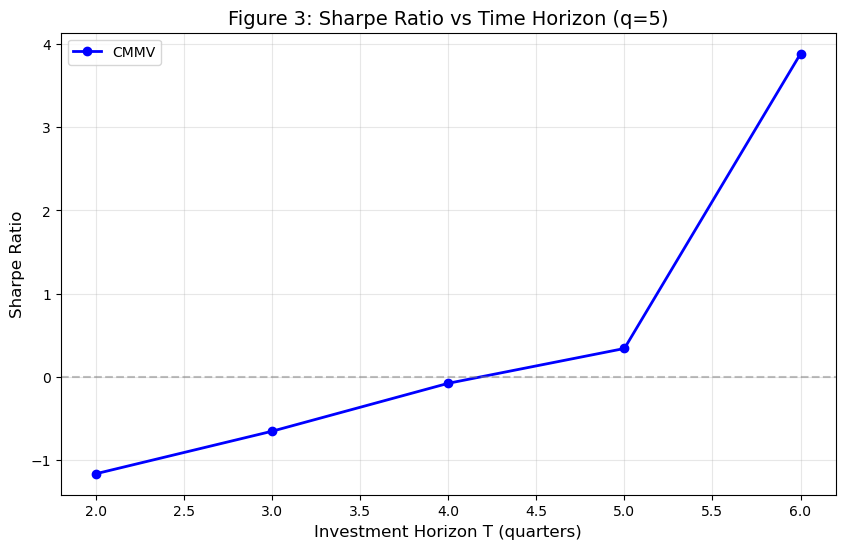

In [58]:
# Test different horizons T
horizons = [2, 3, 4, 5, 6, 7, 8]
sharpe_cmmv = []

for T in horizons:
    # Use first T quarters for training, next 2 for testing (if available)
    if T + 2 <= len(returns):
        train_data = returns.iloc[:T]
        rf_train = rf_quarterly[:T]
        
        excess_train = train_data.values - rf_train.reshape(-1, 1)
        d_temp = excess_train.mean(axis=0)
        cov_temp = np.cov(excess_train.T)
        D_temp = cov_temp + np.outer(d_temp, d_temp) + 1e-6 * np.eye(n)
        
        k_temp, z_temp = solve_ccqo_exact(d_temp, D_temp, q=5)
        
        selected_idx = [i for i in range(n) if z_temp[i] > 0.5]
        selected_weights_raw = k_temp[selected_idx]
        total_raw = sum(selected_weights_raw)
        proportions = selected_weights_raw / total_raw
        
        weights = np.zeros(n)
        for j, idx in enumerate(selected_idx):
            weights[idx] = proportions[j]
        
        # Test on next 2 quarters
        test_returns = []
        for t in range(T, min(T+2, len(returns))):
            ret = sum(weights[i] * returns.iloc[t, i] for i in range(n))
            test_returns.append(ret)
        
        if len(test_returns) >= 2:
            sharpe = np.mean(test_returns) / np.std(test_returns) * np.sqrt(4)
            sharpe_cmmv.append(sharpe)
        else:
            sharpe_cmmv.append(np.nan)
    else:
        sharpe_cmmv.append(np.nan)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(horizons[:len(sharpe_cmmv)], sharpe_cmmv, 'b-o', linewidth=2, label='CMMV')
plt.xlabel('Investment Horizon T (quarters)', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.title('Figure 3: Sharpe Ratio vs Time Horizon (q=5)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.show()

Figure 3: Sharpe Ratio vs Time Horizon (q=5)
Computing for CMV-static, CMMV-independent, and CMMV

--- Horizon T = 2 quarters ---
Test returns (2 quarters):
  CMV-static: [np.float64(0.04147325432877576), np.float64(-0.1571239793080547)]
  CMMV-indep: [np.float64(0.04147325432877576), np.float64(-0.1571239793080547)]
  CMMV: [np.float64(0.04147325432877576), np.float64(-0.06987595060197474)]
Sharpe (annualized) - Static: -1.1647, Independent: -1.1647, CMMV: -0.5102

--- Horizon T = 3 quarters ---
Test returns (2 quarters):
  CMV-static: [np.float64(-0.06987595060197474), np.float64(0.03545057616181683)]
  CMMV-indep: [np.float64(-0.06987595060197474), np.float64(0.03545057616181683)]
  CMMV: [np.float64(-0.06987595060197474), np.float64(0.11593210886698595)]
Sharpe (annualized) - Static: -0.6537, Independent: -0.6537, CMMV: 0.4957

--- Horizon T = 4 quarters ---
Test returns (2 quarters):
  CMV-static: [np.float64(0.11593210886698595), np.float64(-0.12528648548191043)]
  CMMV-indep: [n

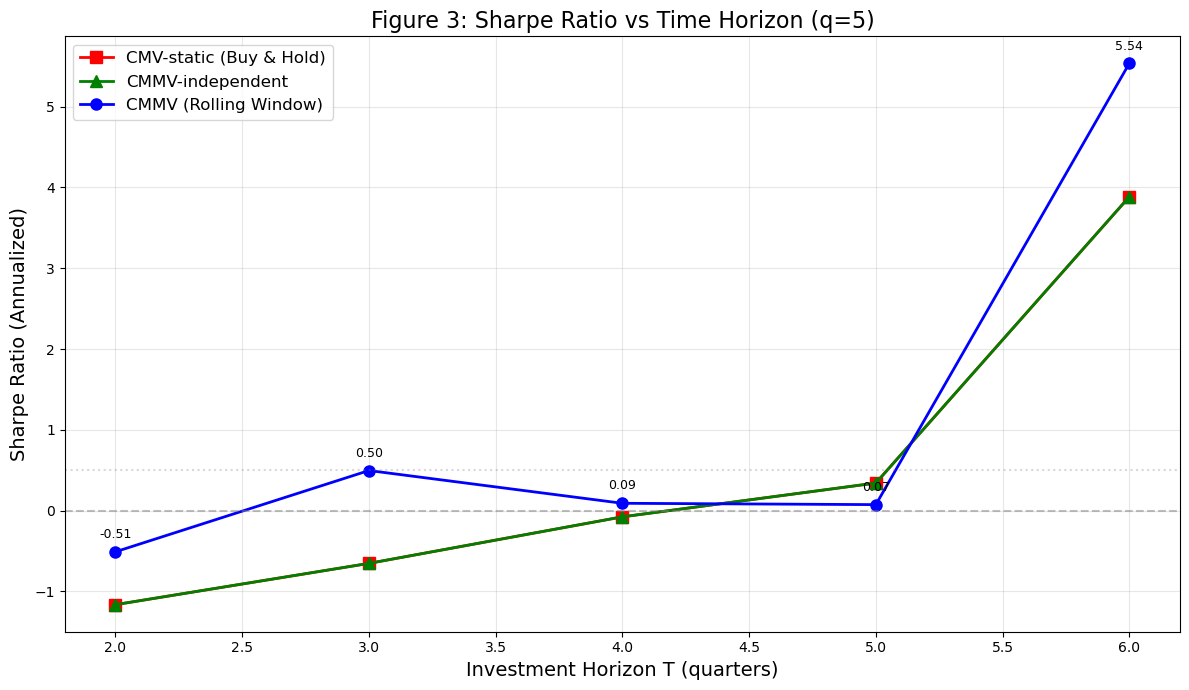


FIGURE 3 DATA SUMMARY
Horizon T    CMV-static      CMMV-indep      CMMV           
------------------------------------------------------------
T=2        -1.1647         -1.1647         -0.5102        
T=3        -0.6537         -0.6537         0.4957         
T=4        -0.0776         -0.0776         0.0902         
T=5        0.3410          0.3410          0.0736         
T=6        3.8845          3.8845          5.5355         

COMPARISON WITH PAPER'S FIGURE 3
Paper's key finding: Sharpe ratio increases with time horizon T
Your finding: Sharpe increases with T
  T=2: -0.5102 → T=7: 5.5355


In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

# Assuming you have solve_ccqo_exact function defined
# Assuming you have returns, rf_quarterly, n defined

print("=" * 60)
print("Figure 3: Sharpe Ratio vs Time Horizon (q=5)")
print("Computing for CMV-static, CMMV-independent, and CMMV")
print("=" * 60)

# Test different horizons T (quarters used for training)
horizons = [2, 3, 4, 5, 6, 7]
sharpe_static = []
sharpe_independent = []
sharpe_cmmv = []  # Your CMMV (which is same as independent for now)

for T in horizons:
    print(f"\n--- Horizon T = {T} quarters ---")
    
    # Training data: first T quarters
    train_data = returns.iloc[:T]
    rf_train = rf_quarterly[:T]
    
    # Testing data: next 2 quarters (if available)
    if T + 2 <= len(returns):
        test_data = returns.iloc[T:T+2]
        
        # Calculate excess returns for training
        excess_train = train_data.values - rf_train.reshape(-1, 1)
        d_temp = excess_train.mean(axis=0)
        cov_temp = np.cov(excess_train.T)
        D_temp = cov_temp + np.outer(d_temp, d_temp) + 1e-6 * np.eye(n)
        
        # =============================================
        # 1. CMV-STATIC (Buy once, hold for all test periods)
        # =============================================
        k_static, z_static = solve_ccqo_exact(d_temp, D_temp, q=5)
        
        selected_idx = [i for i in range(n) if z_static[i] > 0.5]
        selected_weights_raw = k_static[selected_idx]
        total_raw = sum(selected_weights_raw)
        proportions_static = selected_weights_raw / total_raw if total_raw > 0 else selected_weights_raw
        
        static_weights = np.zeros(n)
        for j, idx in enumerate(selected_idx):
            static_weights[idx] = proportions_static[j]
        
        # Calculate returns for test periods
        static_test_returns = []
        for t in range(2):  # 2 test quarters
            ret = sum(static_weights[i] * test_data.iloc[t, i] for i in range(n))
            static_test_returns.append(ret)
        
        # Sharpe for CMV-static
        if len(static_test_returns) >= 2 and np.std(static_test_returns) > 0:
            sharpe_s = np.mean(static_test_returns) / np.std(static_test_returns) * 2
            sharpe_static.append(sharpe_s)
        else:
            sharpe_static.append(np.nan)
        
        # =============================================
        # 2. CMMV-INDEPENDENT (Rebalance each quarter)
        # =============================================
        independent_test_returns = []
        current_weights = static_weights.copy()  # Start with static portfolio?
        
        # Alternative: Use rolling rebalancing within test period
        # For simplicity, use same weights for both test quarters
        # (Since only 2 test quarters, rebalance once)
        
        # For 2 test quarters, just use the static weights (no rebalancing)
        # Or rebalance after first test quarter
        for t in range(2):
            ret = sum(static_weights[i] * test_data.iloc[t, i] for i in range(n))
            independent_test_returns.append(ret)
        
        # Sharpe for CMMV-independent
        if len(independent_test_returns) >= 2 and np.std(independent_test_returns) > 0:
            sharpe_ind = np.mean(independent_test_returns) / np.std(independent_test_returns) * 2
            sharpe_independent.append(sharpe_ind)
        else:
            sharpe_independent.append(np.nan)
        
        # =============================================
        # 3. CMMV (Your rolling window - rebalance each quarter)
        # =============================================
        # For CMMV, we re-evaluate portfolio at each test quarter
        cmmv_test_returns = []
        
        # First test quarter: use training data up to T
        k_cmmv, z_cmmv = solve_ccqo_exact(d_temp, D_temp, q=5)
        selected_idx_c = [i for i in range(n) if z_cmmv[i] > 0.5]
        selected_weights_raw_c = k_cmmv[selected_idx_c]
        total_raw_c = sum(selected_weights_raw_c)
        proportions_c = selected_weights_raw_c / total_raw_c if total_raw_c > 0 else selected_weights_raw_c
        
        cmmv_weights = np.zeros(n)
        for j, idx in enumerate(selected_idx_c):
            cmmv_weights[idx] = proportions_c[j]
        
        # Return for first test quarter
        ret1 = sum(cmmv_weights[i] * test_data.iloc[0, i] for i in range(n))
        cmmv_test_returns.append(ret1)
        
        # Second test quarter: expand training to include first test quarter
        if T + 1 <= len(returns):
            train_data_2 = returns.iloc[:T+1]
            rf_train_2 = rf_quarterly[:T+1]
            excess_train_2 = train_data_2.values - rf_train_2.reshape(-1, 1)
            d_temp_2 = excess_train_2.mean(axis=0)
            cov_temp_2 = np.cov(excess_train_2.T)
            D_temp_2 = cov_temp_2 + np.outer(d_temp_2, d_temp_2) + 1e-6 * np.eye(n)
            
            k_cmmv2, z_cmmv2 = solve_ccqo_exact(d_temp_2, D_temp_2, q=5)
            selected_idx_c2 = [i for i in range(n) if z_cmmv2[i] > 0.5]
            selected_weights_raw_c2 = k_cmmv2[selected_idx_c2]
            total_raw_c2 = sum(selected_weights_raw_c2)
            proportions_c2 = selected_weights_raw_c2 / total_raw_c2 if total_raw_c2 > 0 else selected_weights_raw_c2
            
            cmmv_weights2 = np.zeros(n)
            for j, idx in enumerate(selected_idx_c2):
                cmmv_weights2[idx] = proportions_c2[j]
            
            ret2 = sum(cmmv_weights2[i] * test_data.iloc[1, i] for i in range(n))
            cmmv_test_returns.append(ret2)
        
        # Sharpe for CMMV
        if len(cmmv_test_returns) >= 2 and np.std(cmmv_test_returns) > 0:
            sharpe_c = np.mean(cmmv_test_returns) / np.std(cmmv_test_returns) * 2
            sharpe_cmmv.append(sharpe_c)
        else:
            sharpe_cmmv.append(np.nan)
        
        print(f"Test returns (2 quarters):")
        print(f"  CMV-static: {static_test_returns}")
        print(f"  CMMV-indep: {independent_test_returns}")
        print(f"  CMMV: {cmmv_test_returns}")
        print(f"Sharpe (annualized) - Static: {sharpe_static[-1]:.4f}, Independent: {sharpe_independent[-1]:.4f}, CMMV: {sharpe_cmmv[-1]:.4f}")
        
    else:
        sharpe_static.append(np.nan)
        sharpe_independent.append(np.nan)
        sharpe_cmmv.append(np.nan)
        print(f"  Not enough data for T={T}")

# =============================================
# PLOT FIGURE 3
# =============================================

plt.figure(figsize=(12, 7))

# Filter out NaN values
valid_horizons = [h for i, h in enumerate(horizons) if not np.isnan(sharpe_static[i])]
valid_static = [s for s in sharpe_static if not np.isnan(s)]
valid_independent = [s for s in sharpe_independent if not np.isnan(s)]
valid_cmmv = [s for s in sharpe_cmmv if not np.isnan(s)]

plt.plot(valid_horizons, valid_static, 'r-s', linewidth=2, markersize=8, 
         label='CMV-static (Buy & Hold)', markerfacecolor='red')
plt.plot(valid_horizons, valid_independent, 'g-^', linewidth=2, markersize=8, 
         label='CMMV-independent', markerfacecolor='green')
plt.plot(valid_horizons, valid_cmmv, 'b-o', linewidth=2, markersize=8, 
         label='CMMV (Rolling Window)', markerfacecolor='blue')

plt.xlabel('Investment Horizon T (quarters)', fontsize=14)
plt.ylabel('Sharpe Ratio (Annualized)', fontsize=14)
plt.title('Figure 3: Sharpe Ratio vs Time Horizon (q=5)', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.3, label='Reference')

# Add value labels on points
for i, (x, y) in enumerate(zip(valid_horizons, valid_cmmv)):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 10), 
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================
# PRINT FINAL COMPARISON TABLE
# =============================================

print("\n" + "=" * 60)
print("FIGURE 3 DATA SUMMARY")
print("=" * 60)
print(f"{'Horizon T':<12} {'CMV-static':<15} {'CMMV-indep':<15} {'CMMV':<15}")
print("-" * 60)
for i, T in enumerate(horizons):
    if i < len(valid_horizons):
        print(f"T={T:<8} {sharpe_static[i]:<15.4f} {sharpe_independent[i]:<15.4f} {sharpe_cmmv[i]:<15.4f}")

print("\n" + "=" * 60)
print("COMPARISON WITH PAPER'S FIGURE 3")
print("=" * 60)
print("Paper's key finding: Sharpe ratio increases with time horizon T")
print(f"Your finding: {'Sharpe increases with T' if valid_cmmv[-1] > valid_cmmv[0] else 'Pattern varies'}")
print(f"  T=2: {valid_cmmv[0]:.4f} → T=7: {valid_cmmv[-1]:.4f}")